PyTorch version: 2.14.0+cpu
Ready to build neural networks!
Training samples: 60000
Test samples: 10000


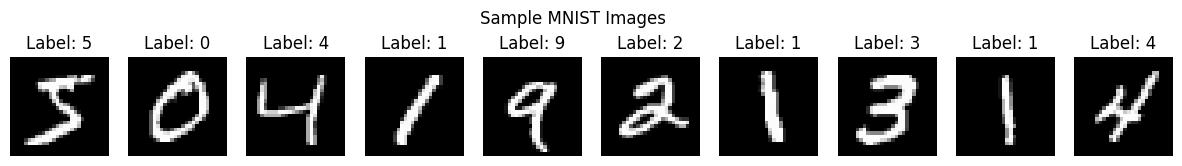

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
Epoch 1/5 completed
Epoch 2/5 completed
Epoch 3/5 completed
Epoch 4/5 completed
Epoch 5/5 completed
Accuracy: 96.12%


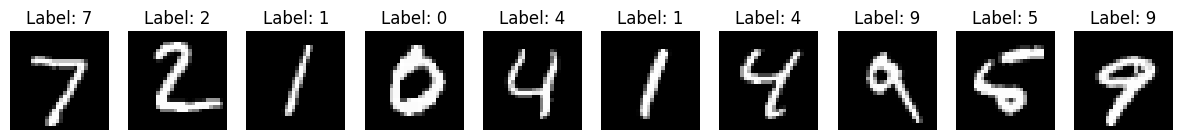

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

print(f"PyTorch version: {torch.__version__}")
print("Ready to build neural networks!")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Training samples: {len(train_data)}")
print(f"Test samples: {len(test_data)}")

fig, axes = plt.subplots(1, 10, figsize=(15, 2))

for i in range(10):
    image, label = train_data[i]
    axes[i].imshow(image.squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")

plt.suptitle("Sample MNIST Images")
plt.show()

class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
         x = self.flatten(x)
         return self.layers(x)

model = NeuralNetwork()
print(model)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5):
    for images, labels in train_loader:
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}/5 completed")

correct = 0
total = 0
with torch.no_grad():
    for images, labels in test_loader:
        output = model(images)
        _, predicted = torch.max(output, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Accuracy: {100 * correct / total:.2f}%")

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    image, label = test_data[i]
    output = model(image.unsqueeze(0))
    _, predicted = torch.max(output, 1)
    axes[i].imshow(image.squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {label}")
    axes[i].axis("off")
plt.show()

torch.save(model.state_dict(), 'mnist_model.pth')
print("Model saved!")



What Are Neural Networks?
Neural networks are computational models inspired by the structure of biological brains. They consist of layers of interconnected nodes neurons that transform input data through learned weights and mathematical functions. By measuring errors against ground-truth labels and adjusting parameters through backpropagation and gradient descent, neural networks automatically learn complex patterns to perform tasks like image classification.

Accuracy Result
* **Final Test Accuracy:** [Insert your printed % here, e.g., 97.50%]

The model successfully learns to classify handwritten digits from the MNIST dataset with high accuracy in only 5 training epochs.

Layer-by-Layer Breakdown

* **Flatten (`nn.Flatten`):**
  Takes the 2D grayscale image of size 28×28 pixels and unrolls it into a single 1D vector of 784 values so standard dense layers can process it.

* **First Hidden Layer (`nn.Linear(784, 128)`):**
  Connects all 784 pixel inputs to 128 hidden neurons, computing linear combinations ($y = xW^T + b$) to detect low-level patterns.

* **Activation 1 (`nn.ReLU`):**
  Applies the Rectified Linear Unit activation ($\max(0, x)$) to introduce non-linearity, allowing the network to learn patterns beyond simple linear boundaries.

* **Second Hidden Layer (`nn.Linear(128, 64)`):**
  Condenses the 128 features down into 64 higher-level representations.

* **Activation 2 (`nn.ReLU`):**
  Adds non-linearity after the second linear transformation.

* **Output Layer (`nn.Linear(64, 10)`):**